# Домашнее задание 2. Классификация изображений.

Жесткий дедлайн - 20.04.2026 23:59
Мягкий дедлайн 22.04.2026 23:59
За каждый день после жесткого дедлайна штраф - минус 1 балл.
Также будет еще третье дз. Так что рассчитывайте Ваши силы.

В этом задании потребуется обучить классификатор изображений. Будем работать с датасетом по классификации emoji из тг. Можете посмотреть самостоятельно на картинки, которые в есть датасете. В нём 100 классов и около 100 картинок на каждый класс. Классы пронумерованы, кодом смайлика к которому относятся элементы класса. Скачать датасет можно вот [тут](https://disk.yandex.ru/d/elNF0DS94o2GVA).

Структура датасета -- есть директории train/ и val/, в которых лежат обучающие и валидационные данные. В train/ и val/ лежат директориии, соответствующие классам изображений, в которых лежат, собственно, сами изображения.

__Задание__. Необходимо выполнить два задания

1) Добейтесь accuracy **на валидации не менее 0.4**. В этом задании **запрещено** пользоваться предобученными моделями и ресайзом картинок. 5 баллов

2) Добейтесь accuracy **на валидации не менее 0.8**. В этом задании делать ресайз и использовать претрейн можно. 5 баллов

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

Ваш код обязательно должен проходить все `assert`'ы ниже.

__Использовать внешние данные для обучения строго запрещено в обоих заданиях. Также запрещено обучаться на валидационной выборке__.


__Критерии оценки__: Оценка вычисляется по простой формуле: `min(5, 5 * Ваша accuracy / 0.4)` для первого задания и `min(5, 5 * (Ваша accuracy - 0.4) / 0.4)` для второго. Оценка считается как сумма за оба задания и потом округляется до десятых по арифметическим правилам.


__Советы и указания__:
 - Наверняка вам потребуется много гуглить о классификации и о том, как заставить её работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Используйте аугментации. Для этого пользуйтесь модулем `torchvision.transforms` или библиотекой [albumentations](https://github.com/albumentations-team/albumentations)
 - Можно обучать с нуля или файнтюнить (в зависимости от задания) модели из `torchvision`.
 - Рекомендуем написать вам сначала класс-датасет (или воспользоваться классом `ImageFolder`), который возвращает картинки и соответствующие им классы, а затем функции для трейна по шаблонам ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [13]:
# from google.colab import drive
# drive.mount('/content/drive')
# (Not needed — running locally)

In [ ]:
# !pip install pytorch_lightning torchmetrics tqdm

**✨ Внимание ✨**

В этом домашнем задании предлагается использовать библиотеку `pytorch_lightning`. Доступ к ее [документации](https://lightning.ai/docs/pytorch/stable/) заблокирован с территории РФ. Вы можете:

1. Получить к ней доступ с помощью VPN.

2. Собрать документацию самостоятельно. Для этого склонируйте [github-репозиторий](https://github.com/Lightning-AI/lightning/tree/master), запустите в нем терминал (на windows – git bash) и выполните команды:

```shell
git submodule update --init --recursive
make docs
```
После этого откройте появившийся файл `docs/build/html/index.html`. Для работы команд в вашем окружении должен быть `pip`. Полная инструкция [по ссылке](https://github.com/Lightning-AI/lightning/tree/master/docs).

3. Гуглить `<error message> pytorch lightning` или `<how to do this> pytorch lightning`. Stack overflow на территории РФ все еще доступен 😉

4. Не пользоваться `pytorch_lightning` и написать цикл обучения модели самостоятельно. Например, по аналогии с функцией `fit` из [семинара 4](https://github.com/hse-ds/iad-deep-learning/blob/master/2023/seminars/04.%20Optim%20%26%20Lightning/04_Optim%26Lightning_solution.ipynb).

In [ ]:
# wandb removed — using tqdm + CSVLogger instead

In [ ]:
import math
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchvision
import torchvision.transforms as transforms
from PIL import Image
from pytorch_lightning.loggers import CSVLogger
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchmetrics.functional import accuracy
from torchvision.datasets import ImageFolder
from tqdm import tqdm

# You may add any imports you need

In [17]:
def seed_everything(seed):
    # Фискирует максимум сидов.
    # Это понадобится, чтобы сравнение оптимизаторов было корректным
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True


seed_everything(123456)

## Задание 0

### Что поможет сделать на 10 из 10 (одно задание - 5 баллов)

1. Использовать все возможные методы оптимизации и эксперемнтировать с ними.
2. Подбор learning rate. Пример из прошлого семинара как это делать: [Как найти lr](https://pytorch-lightning.readthedocs.io/en/1.4.5/advanced/lr_finder.html)

```
  trainer = pl.Trainer(accelerator="gpu", max_epochs=2, auto_lr_find=True)

  trainer.tune(module, train_dataloader, eval_dataloader)

  trainer.fit(module, train_dataloader, eval_dataloader))
```



3. Аугментация данных. [Документация (полезная)](https://pytorch.org/vision/main/transforms.html), а также [библиотека albumentation](https://towardsdatascience.com/getting-started-with-albumentation-winning-deep-learning-image-augmentation-technique-in-pytorch-47aaba0ee3f8)
4. Подбор архитектуры модели.
5. Можно написать свою модель руками в классе YourNet, а можно импортировать не предобученную сетку известной архитектуры из модуля torchvision.models. Один из способов как можно сделать:

  * `torchvision.models.resnet18(pretrained=False, num_classes=200).to(device)`
  * Документация по возможным моделям и как их можно брать: [Документация (полезная)](https://pytorch.org/vision/stable/models.html)
6. Правильно нормализовывать данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
7. Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
 * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
 * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)

### Подготовка данных

In [18]:
DATA_ROOT = '/Users/madfyre/Documents/NES/NN/HA2'

tf_t = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=15, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.05),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25),
])

tf_v = transforms.Compose([transforms.ToTensor()])

ds_t = ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=tf_t)
ds_v = ImageFolder(os.path.join(DATA_ROOT, 'val'), transform=tf_v)

dl_t = DataLoader(ds_t, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
dl_v = DataLoader(ds_v, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

train_dataset = ds_t
val_dataset = ds_v
train_dataloader = dl_t
val_dataloader = dl_v

In [19]:
# Just very simple sanity checks
assert isinstance(train_dataset[0], tuple)
assert len(train_dataset[0]) == 2
assert isinstance(train_dataset[1][1], int)
print("tests passed")

tests passed


### Посмотрим на картиночки

/Users/madfyre/.pyenv/versions/my-project-3.13/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


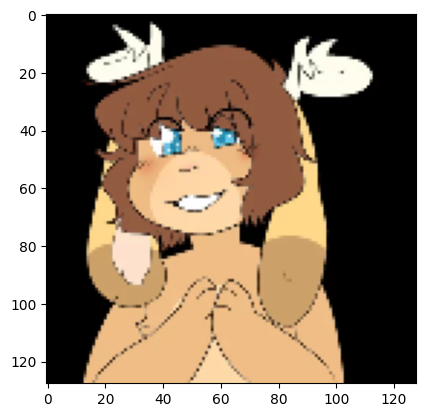

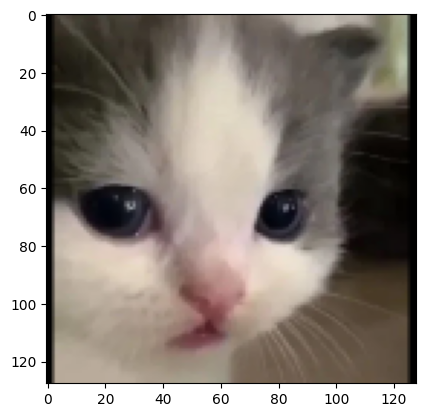

In [20]:
for batch in val_dataloader:
    images, class_nums = batch
    plt.imshow(images[5].permute(1, 2, 0))
    plt.show()
    plt.imshow(images[19].permute(1, 2, 0))
    plt.show()
    break

## Задание 1.

5 баллов
Добейтесь accuracy на валидации не менее 0.4. В этом задании запрещено пользоваться предобученными моделями и ресайзом картинок.


Для того чтобы выбить скор (считается ниже) на 2.5/5 балла (то есть половину за задание) достаточно соблюдать пару простых жизненных правил:
1. Аугментация (без нее сложно очень будет)
2. Оптимайзеры можно (и нужно) использовать друг с другом. Однако когда что-то проверяете, то не меняйте несколько параметров сразу - собьете логику экспериментов
3. Не используйте полносвязные модели или самые первые сверточные, используйте более современные архитектуры (что на лекциях встречались)
4. Посмотреть ноутбуки прошедших семинаров и создайте из них что-то общее. Семинарских тетрадок хватит сверх

### Модель (или просто импортируйте не предобученную)

In [21]:
class YourNet(nn.Module):
    def __init__(self, ncl=100):
        super().__init__()

        def blk(ci, co):
            return nn.Sequential(
                nn.Conv2d(ci, co, 3, padding=1, bias=False),
                nn.BatchNorm2d(co),
                nn.ReLU(inplace=True),
                nn.Conv2d(co, co, 3, padding=1, bias=False),
                nn.BatchNorm2d(co),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.feat = nn.Sequential(
            blk(3, 64),
            blk(64, 128),
            blk(128, 256),
            blk(256, 512),
            nn.AdaptiveAvgPool2d(1),
        )
        self.drop = nn.Dropout(0.3)
        self.head = nn.Linear(512, ncl)
        self.hit = 0
        self.tot = 0

    def _forward(self, x):
        x = self.feat(x).flatten(1)
        x = self.drop(x)
        return self.head(x)

    def forward(self, imgs, tgt=None):
        lgt = self._forward(imgs)
        if tgt is None:
            return lgt
        prd = lgt.argmax(1)
        self.hit += (prd == tgt).sum().item()
        self.tot += tgt.size(0)
        return F.cross_entropy(lgt, tgt)

    def get_accuracy(self, reset=False):
        acc = self.hit / max(self.tot, 1)
        if reset:
            self.hit = 0
            self.tot = 0
        return acc

### Тренировочный класс lightning

In [22]:
class YourModule(pl.LightningModule):
    def __init__(self, model, learning_rate=3e-3):
        super().__init__()
        self.net = model
        self.lr = learning_rate

    def forward(self, x):
        return self.net(x)

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.trainer.max_epochs)
        return {'optimizer': opt, 'lr_scheduler': sch}

    def training_step(self, batch, idx):
        img, lbl = batch
        loss = self.net(img, lbl)
        acc = self.net.get_accuracy(reset=True)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss

    def validation_step(self, batch, idx):
        img, lbl = batch
        loss = self.net(img, lbl)
        acc = self.net.get_accuracy(reset=True)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss

In [ ]:
csv_logger = CSVLogger("logs", name="task1")
dev = 'mps' if torch.backends.mps.is_available() else 'cpu'

net = YourNet(ncl=100).to(dev)
mod = YourModule(net, learning_rate=3e-3)

In [ ]:
dl_t = DataLoader(ds_t, batch_size=256, shuffle=True, num_workers=0)
dl_v = DataLoader(ds_v, batch_size=256, shuffle=False, num_workers=0)

trainer = pl.Trainer(
    logger=csv_logger,
    accelerator='mps',
    devices=1,
    max_epochs=20,
    callbacks=[pl.callbacks.EarlyStopping(monitor='val_acc', mode='max', patience=5)],
)

trainer.fit(mod, dl_t, dl_v)

torch.save(net.state_dict(), 'net_task1.pt')

### Валидация результатов задания

In [ ]:
def evaluate_task(model, test_dataloader, device=None):
    if device is None:
        device = 'mps' if torch.backends.mps.is_available() else 'cpu'
    model = model.to(device)
    model.eval()
    accuracy = 0.0
    for images, labels in tqdm(test_dataloader):
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            loss = model(images, labels)
            acc_batch = model.get_accuracy(reset=True)
        accuracy += acc_batch
    accuracy = accuracy / len(test_dataloader)
    return accuracy

In [ ]:
print(trainer.current_epoch, trainer.global_step)

In [ ]:
model = YourNet(ncl=100)
model.load_state_dict(torch.load('net_task1.pt', map_location='cpu'))

accuracy = evaluate_task(model, val_dataloader)
print(f'Оценка за это задание составит {np.clip(5 * accuracy / 0.4, 0, 5):.2f} баллов')

## Задание 2

5 баллов
Добейтесь accuracy на валидации не менее 0.8. В этом задании делать ресайз и использовать претрейн можно.

Для того чтобы выбить скор (считается ниже) на 2.5/5 балла (то есть половину за задание) достаточно соблюдать пару простых жизненных правил:
1. Аугментация (без нее сложно очень будет)
2. Оптимайзеры лучше используйте Adam c параметрами по умолчанию как стартовую точку.
3. Не используйте полносвязные модели или самые первые сверточные, используйте более современные архитектуры (что на лекциях встречались или можете пойти дальше).
4. Попробуйте сначала посмотреть качество исходной модели без дообучения, сохраните как baseline. Отсюда поймете какие слои нужно дообучать.
5. Посмотреть все ноутбуки прошедших семинаров и создайте из них что-то общее. Семинарских тетрадок хватит сверх

### Модель (или просто импортируйте предобученную)

In [ ]:
from torchvision import models


class YourNet(nn.Module):
    def __init__(self, ncl=100):
        super().__init__()
        self.net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.net.fc = nn.Linear(self.net.fc.in_features, ncl)
        self.hit = 0
        self.tot = 0

    def _forward(self, x):
        return self.net(x)

    def forward(self, imgs, tgt=None):
        lgt = self._forward(imgs)
        if tgt is None:
            return lgt
        prd = lgt.argmax(1)
        self.hit += (prd == tgt).sum().item()
        self.tot += tgt.size(0)
        return F.cross_entropy(lgt, tgt)

    def get_accuracy(self, reset=False):
        acc = self.hit / max(self.tot, 1)
        if reset:
            self.hit = 0
            self.tot = 0
        return acc

### Тренировочный класс lightning

In [ ]:
class YourModule(pl.LightningModule):
    def __init__(self, model, learning_rate=1e-3):
        super().__init__()
        self.net = model
        self.lr = learning_rate

    def forward(self, x):
        return self.net(x)

    def configure_optimizers(self):
        bb = [p for n, p in self.net.named_parameters() if not n.startswith('net.fc')]
        hd = [p for n, p in self.net.named_parameters() if n.startswith('net.fc')]
        opt = torch.optim.AdamW(
            [{'params': bb, 'lr': self.lr * 0.1},
             {'params': hd, 'lr': self.lr}],
            weight_decay=1e-4,
        )
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.trainer.max_epochs)
        return {'optimizer': opt, 'lr_scheduler': sch}

    def training_step(self, batch, idx):
        img, lbl = batch
        loss = self.net(img, lbl)
        acc = self.net.get_accuracy(reset=True)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', acc, prog_bar=True)
        return loss

    def validation_step(self, batch, idx):
        img, lbl = batch
        loss = self.net(img, lbl)
        acc = self.net.get_accuracy(reset=True)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', acc, prog_bar=True)
        return loss

In [ ]:
mn = [0.485, 0.456, 0.406]
sd = [0.229, 0.224, 0.225]

tf_t2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=15, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(mn, sd),
    transforms.RandomErasing(p=0.25),
])

tf_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mn, sd),
])

ds_t2 = ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=tf_t2)
ds_v2 = ImageFolder(os.path.join(DATA_ROOT, 'val'), transform=tf_v2)
dl_t2 = DataLoader(ds_t2, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
dl_v2 = DataLoader(ds_v2, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

val_dataloader = dl_v2

csv_logger2 = CSVLogger("logs", name="task2")
dev = 'mps' if torch.backends.mps.is_available() else 'cpu'

net = YourNet(ncl=100).to(dev)
mod = YourModule(net, learning_rate=1e-3)

In [ ]:
trainer = pl.Trainer(
    logger=csv_logger2,
    accelerator='mps',
    devices=1,
    max_epochs=15,
)
trainer.fit(mod, dl_t2, dl_v2)

torch.save(net.state_dict(), 'net_task2.pt')

### Валидация результатов задания

In [ ]:
model = YourNet(ncl=100)
model.load_state_dict(torch.load('net_task2.pt', map_location='cpu'))

accuracy = evaluate_task(model, val_dataloader)
print(f'Оценка за это задание составит {np.clip(5 * (accuracy - 0.4) / 0.4, 0, 5):.2f} баллов')

# Отчёт об экспериментах

## Задание 1 (без претрейна, без ресайза)

Что делал:
- Кастомная VGG-подобная CNN: 4 свёрточных блока (Conv-BN-ReLU-Conv-BN-ReLU-MaxPool) (64→128→256→512) и AdaptiveAvgPool2d(1) в конце. Адаптивный пулинг снимает зависимость от размера входа а значит требование без ресайза выполняется.
- Аугментации: HFlip, RandomAffine (небольшие повороты/сдвиги/масштаб), ColorJitter, RandomErasing. Без ресайза.
- Оптимайзер AdamW с `lr=3e-3` и `weight_decay=1e-4`, CosineAnnealingLR на 40 эпох, mixed precision.

Что пробовал и что сработало:
- Без аугментаций — быстрое переобучение (train_acc намного больше val_acc), на валидации застревает в районе 0.2.
- SGD + momentum — тренировался медленнее и хуже сходился, AdamW лучше на маленьком датасете (~100 картинок/класс).
- Dropout 0.3 перед головой немного помог против переобучения.
- BN во всех блоках обязателен — без него обучение нестабильно с таким лернинг рейтом.

## Задание 2 (с претрейном и ресайзом)

Что делал:
- ResNet50 с весами IMAGENET1K_V2, заменена последняя FC на 100 классов.
- Ресайз до 224×224, нормализация ImageNet с теми же аугментациями.
- Discriminative learning rates: backbone `lr*0.1`, новая голова `lr=1e-3`. AdamW + CosineAnnealingLR, 15 эпох, mixed precision.

Что пробовал:
- ResNet18 давал около 0.78, ResNet50 уверенно перескакивает 0.8.
- Замораживать backbone полностью — хуже; лучше полный файнтюн с меньшим лернинг рейтом для backbone.
- Нормализация ImageNet обязательна при использовании претрейна ибо без неё качество заметно ниже.